In [1]:
from pathlib import Path
import pandas as pd
import hashlib
from sklearn.model_selection import train_test_split
import random
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch
from collections import Counter
import torchvision.models as models
import torch.nn as nn
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm


BATCH_SIZE = 32
NUM_WORKERS = 0
IMG_SIZE = 224
SEED = 42

# ---- Model ----
NUM_CLASSES = 5
PRETRAINED = True

# ---- Training ----
NUM_EPOCHS = 30
LR = 5e-5
WEIGHT_DECAY = 1e-3
EARLY_STOP_PATIENCE = 8
CHECKPOINT_DIR = "/Users/jackxia/Desktop/Python/DFU Project/checkpoints"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

In [2]:


#image loading

root_dir = Path("/Users/jackxia/Desktop/Python/DFU Project/03-Diabetic_Foot_Ulcers_(DFU)")
data_format = {".jpg", ".jpeg", ".png"}
data = []


for folder in root_dir.iterdir():
    if not folder.is_dir():
        continue
    label = int(folder.name.split()[-1])
    for file in folder.iterdir():
        if file.is_file and file.suffix.lower() in data_format:
            data.append((str(file),label))

df = pd.DataFrame(data, columns = ["path","label"])
print(df['label'].value_counts().sort_index())
print(f"Total images: {len(df)}")

#duplicate removal
def md5_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df["md5"] = df["path"].apply(md5_hash)
print(f"dups: {df["md5"].duplicated().sum()}")

df = df.drop_duplicates(subset = 'md5', keep = 'first').reset_index(drop = True)
print("\nClass distribution after dedup:")
print(df['label'].value_counts().sort_index())
print(f"Total images: {len(df)}")

#data split
trainval, test_df = train_test_split(df, test_size = 0.15, stratify = df["label"], random_state = SEED)
train_df, val_df = train_test_split(trainval, test_size = 15/85, stratify = trainval["label"], random_state = SEED)
test_df = test_df.reset_index(drop = True)
train_df = train_df.reset_index(drop = True)
val_df = val_df.reset_index(drop = True)

# Verify no overlap
assert set(train_df['path']) & set(val_df['path']) == set(), "Train/val overlap!"
assert set(train_df['path']) & set(test_df['path']) == set(), "Train/test overlap!"
assert set(val_df['path']) & set(test_df['path']) == set(), "Val/test overlap!"

# Verify sizes
print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df):.1%})")

print("\nClass proportions per split:")
comparison = pd.DataFrame({
    'train': train_df['label'].value_counts(normalize=True).sort_index(),
    'val':   val_df['label'].value_counts(normalize=True).sort_index(),
    'test':  test_df['label'].value_counts(normalize=True).sort_index(),
})
for idx, row in comparison.iterrows():
    print(f"Class {idx}: train={row['train']:.4f}, val={row['val']:.4f}, test={row['test']:.4f}")

# Save splits to CSV
train_df.to_csv('train.csv', index=False)
val_df.to_csv('val.csv', index=False)
test_df.to_csv('test.csv', index=False)
print("\nSaved train.csv, val.csv, test.csv")

label
0    1238
1     479
2    1633
3     287
4     250
Name: count, dtype: int64
Total images: 3887
dups: 1

Class distribution after dedup:
label
0    1237
1     479
2    1633
3     287
4     250
Name: count, dtype: int64
Total images: 3886
Train: 2720 (70.0%)
Val:   583 (15.0%)
Test:  583 (15.0%)

Class proportions per split:
Class 0: train=0.3184, val=0.3173, test=0.3190
Class 1: train=0.1232, val=0.1235, test=0.1235
Class 2: train=0.4202, val=0.4202, test=0.4202
Class 3: train=0.0739, val=0.0738, test=0.0738
Class 4: train=0.0643, val=0.0652, test=0.0635

Saved train.csv, val.csv, test.csv


In [3]:


class DFUDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop = True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = int(row['label'])
        return img, label



simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#test
dataset = DFUDataset(train_df, transform=simple_transform)
print(f"Dataset size: {len(dataset)}")
img, label = dataset[1000]
print(f"Image shape: {img.shape}")
print(f"Image dtype: {img.dtype}")
print(f"Label: {label} (type: {type(label).__name__})")
print(f"Pixel range: [{img.min():.3f}, {img.max():.3f}]")

Dataset size: 2720
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: 2 (type: int)
Pixel range: [0.004, 1.000]


In [4]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training pipeline — random augmentation each call
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),  # feet have no canonical orientation in photos
    transforms.RandomRotation(degrees=30),  # was 15
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),  # lighting variation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # small shifts
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),  # occlusion-like
])

# Eval pipeline — deterministic
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Create the three datasets
train_dataset = DFUDataset(train_df, transform=train_transform)
val_dataset   = DFUDataset(val_df,   transform=eval_transform)
test_dataset  = DFUDataset(test_df,  transform=eval_transform)

In [5]:


#Per class weight(for data imbalance)
class_counts = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / class_counts
sample_weights = train_df['label'].map(class_weights).values

#used to do weighted sampling from dataset, rare cases = more likely to be sampled
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(train_df),
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler, # no shuffle cuz sampler has randomness
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# ---- Sanity check 1: shapes ----
images, labels = next(iter(train_loader))
print(f"\nBatch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")
print(f"Label dtype: {labels.dtype}")

# ---- Sanity check 2: train loader balances classes ----
counter = Counter()
for i, (_, lbls) in enumerate(train_loader):
    counter.update(lbls.tolist())
    if i >= 50:
        break
print(f"\nClass counts over 50 train batches (should be roughly equal):")
print(dict(sorted(counter.items())))

# ---- Sanity check 3: val loader preserves original imbalance ----
counter = Counter()
for _, lbls in val_loader:
    counter.update(lbls.tolist())
print(f"\nClass counts in val (should reflect original imbalance):")
print(dict(sorted(counter.items())))



Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Label dtype: torch.int64


/Users/jackxia/Desktop/Python/venv-hw/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Class counts over 50 train batches (should be roughly equal):
{0: 337, 1: 339, 2: 306, 3: 332, 4: 318}

Class counts in val (should reflect original imbalance):
{0: 185, 1: 72, 2: 245, 3: 43, 4: 38}


In [6]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

model.fc = nn.Sequential(
    nn.Dropout(p = 0.3), 
    nn.Linear(model.fc.in_features,NUM_CLASSES)
    )
model = model.to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

def train_one_epoch(model,loader, device, optimizer, criterion):
    
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.shape[0]
        total += images.shape[0]
        prediction = output.argmax(dim = 1)
        correct += (prediction == labels).sum().item()

    ave_loss = running_loss/total
    accuracy = correct/total

    return ave_loss, accuracy

def evaluate(model,loader, device, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            output = model(images)
            loss = criterion(output, labels)
            
            running_loss += loss.item() * images.shape[0]
            total += images.shape[0]
            prediction = output.argmax(dim = 1)
            correct += (prediction == labels).sum().item()

    ave_loss = running_loss/total
    accuracy = correct/total
    
    return ave_loss, accuracy


Using MPS


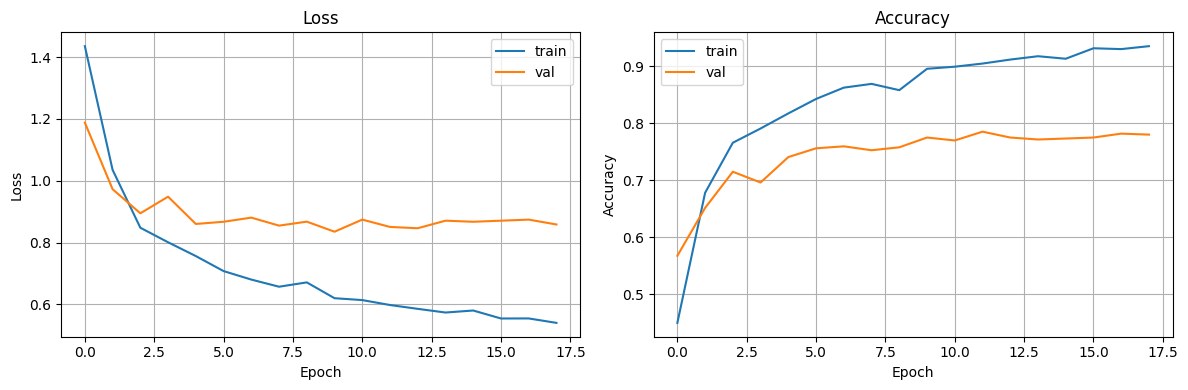

Epoch 18/30 | train_loss=0.5397 train_acc=0.9357 | val_loss=0.8584 val_acc=0.7804
Early stopping at epoch 18

Training done. Best val_loss: 0.8349


In [7]:

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
}

best_val_loss = float('inf')
epochs_without_improvement = 0

def plot_history(history):
    clear_output(wait=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss subplot
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'], label='val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy subplot
    axes[1].plot(history['train_acc'], label='train')
    axes[1].plot(history['val_acc'], label='val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

for i in tqdm(range(NUM_EPOCHS), desc="Epochs"):
    train_loss, train_acc = train_one_epoch(model, train_loader, device, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, device, criterion)
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    plot_history(history)
    
    print(f"Epoch {i+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/resnet50_best.pt")
        print(f"  ↳ New best val_loss, saved checkpoint")
    else:
        epochs_without_improvement += 1
    
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {i+1}")
        break

print(f"\nTraining done. Best val_loss: {best_val_loss:.4f}")

/Users/jackxia/Desktop/Python/venv-hw/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Testing:   0%|          | 0/19 [00:00<?, ?it/s]

Test accuracy: 0.8165
Macro F1: 0.7530

Per-class metrics:
              precision    recall  f1-score   support

           0     0.9427    0.9731    0.9577       186
           1     0.6383    0.8333    0.7229        72
           2     0.8744    0.7388    0.8009       245
           3     0.5106    0.5581    0.5333        43
           4     0.6977    0.8108    0.7500        37

    accuracy                         0.8165       583
   macro avg     0.7327    0.7828    0.7530       583
weighted avg     0.8290    0.8165    0.8183       583


Confusion matrix:
[[181   4   1   0   0]
 [  2  60   9   0   1]
 [  8  25 181  22   9]
 [  0   2  14  24   3]
 [  1   3   2   1  30]]


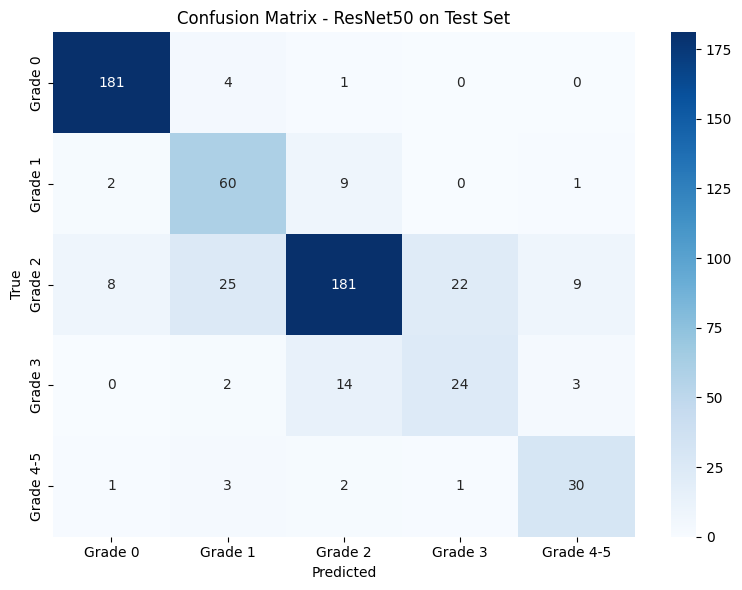

In [9]:
#Testing

model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/resnet50_best.pt"))
model = model.to(device)

def get_prediction(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
         for images, labels in tqdm(loader, desc="Testing", leave=False):
            images = images.to(device)
            output = model(images)
            preds = output.argmax(dim=1)
            
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.tolist())
    
    return all_preds, all_labels

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

all_preds, all_labels = get_prediction(model, test_loader, device)

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"Test accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

# Per-class breakdown
print("\nPer-class metrics:")
print(classification_report(all_labels, all_preds, digits=4))

# Confusion matrix as raw numbers
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion matrix:")
print(cm)

import seaborn as sns

class_names = ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4-5']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, fmt='d', 
            cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - ResNet50 on Test Set')
plt.tight_layout()
plt.show()